In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import timm
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import json
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0
Using device: cpu


In [51]:
from torch.utils.data import Dataset
from PIL import Image

class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        path = self.image_paths[i]
        image = Image.open(path).convert('RGB')
        label = self.labels[i]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label
    
DATA_PATH = "../data/Brain Tumor CT scan Images"
image_paths = []
labels = []

class_map = {'Healthy' : 0, 'Tumor' : 1}

for class_name, label in class_map.items():
    class_path = os.path.join(DATA_PATH, class_name)
    images = [f for f in os.listdir(class_path) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_name in images:
        labels.append(label)
        image_path = os.path.join(class_path, img_name)
        image_paths.append(image_path)
        
print(image_paths[3900])

print(f"Total images collected: {len(image_paths)}")
print(f"Label distribution: {np.bincount(labels)}")

../data/Brain Tumor CT scan Images/Tumor/ct_tumor (88).jpg
Total images collected: 4618
Label distribution: [2300 2318]


In [52]:
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from datetime import datetime
import json
import os

train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, labels,
    test_size = 0.15,
    random_state = 42,
    stratify = labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size = 0.176,
    random_state = 42,
    stratify = train_val_labels
)

print(f"Train: {len(train_paths)} ({len(train_paths)/len(image_paths)*100:.1f}%)")
print(f"Val: {len(val_paths)} ({len(val_paths)/len(image_paths)*100:.1f}%)")
print(f"Test: {len(test_paths)} ({len(test_paths)/len(image_paths)*100:.1f}%)")

print(f"Train distribution: {np.bincount(train_labels)}")
print(f"Val distribution: {np.bincount(val_labels)}")
print(f"Test distribution: {np.bincount(test_labels)}")

split_info = {
    'train_paths': train_paths,
    'val_paths': val_paths,
    'test_paths': test_paths,
    'train_size': len(train_paths),
    'val_size': len(val_paths),
    'test_size': len(test_paths),
    'random_seed': 42,
    'train_distribution': np.bincount(train_labels).tolist(),
    'val_distribution': np.bincount(val_labels).tolist(),
    'test_distribution': np.bincount(test_labels).tolist()
}

os.makedirs('../models', exist_ok = True)
with open(os.path.join('../models', 'data_splits.json'), 'w') as f:
    json.dump(split_info, f, indent=2)

Train: 3234 (70.0%)
Val: 691 (15.0%)
Test: 693 (15.0%)
Train distribution: [1611 1623]
Val distribution: [344 347]
Test distribution: [345 348]


In [53]:
# Image preprocessing and augmentation
IMG_SIZE = 224  # Standard for pretrained models

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Brains are symmetric
    transforms.RandomRotation(degrees=10),    # Slight rotation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Lighting variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                        std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = BrainTumorDataset(train_paths, train_labels, transform=train_transform)
val_dataset = BrainTumorDataset(val_paths, val_labels, transform=val_transform)
test_dataset = BrainTumorDataset(test_paths, test_labels, transform=val_transform)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataloaders created:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")



Dataloaders created:
Train batches: 102
Val batches: 22
Test batches: 22


In [54]:
import timm

def create_model(num_classes=2, pretrained=True):
    model = timm.create_model(
        'efficientnet_b0', 
        pretrained = pretrained,
        num_classes = num_classes
    )
    
    return model

model = create_model(num_classes=2, pretrained=True)
model = model.to(device)

print(f"Model created: EfficientNet-B0")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model created: EfficientNet-B0
Parameters: 4,010,110
Trainable parameters: 4,010,110


In [55]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 102
Val batches: 22
Test batches: 22


In [ ]:
criterion = nn.CrossEntropyLoss()  # Standard for classification

# Use Adam optimizer with learning rate scheduling
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Learning rate scheduler (reduces LR when validation loss plateaus)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3
)

print("Training setup complete!")

In [47]:
# Cell 7: Training Loop
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': running_loss/total, 'acc': 100.*correct/total})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

In [ ]:
# Cell 8: Execute Training
NUM_EPOCHS = 15  # Adjust based on your time budget

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, '../models/best_model.pth')
        print(f"✓ Saved best model (val_acc: {val_acc:.2f}%)")

In [ ]:
# Evaluate on test set - ONLY RUN ONCE!
checkpoint = torch.load('../models/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# Calculate required metrics [1]
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Healthy', 'Tumor']))

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

print(f"\nROC-AUC Score: {roc_auc_score(all_labels, all_probs):.4f}")

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Test Set Confusion Matrix')
plt.savefig('../models/test_confusion_matrix.png')
plt.show()

In [60]:
test_results = {
    'test_accuracy': accuracy_score(all_labels, all_preds),
    'roc_auc': roc_auc_score(all_labels, all_probs),
    'classification_report': classification_report(all_labels, all_preds, 
                                                  target_names=['Healthy', 'Tumor'],
                                                  output_dict=True),
    'confusion_matrix': cm.tolist(),
    'model_version': 'v0.1.0',
    'evaluation_date': datetime.now().isoformat()
}

with open('../models/test_results.json', 'w') as f:
    json.dump(test_results, f, indent=2)

In [58]:
print(history.keys())

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])


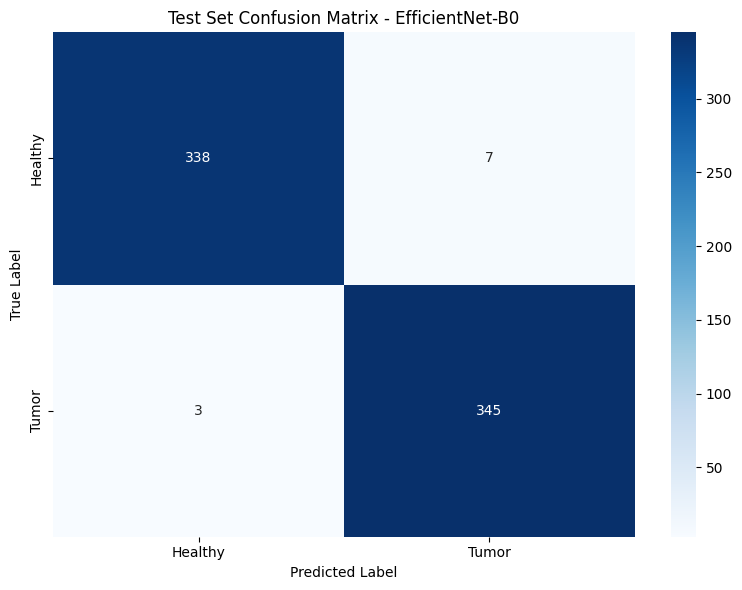

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create docs folder if it doesn't exist
os.makedirs('../docs', exist_ok=True)

# Save Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Tumor'],
            yticklabels=['Healthy', 'Tumor'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Test Set Confusion Matrix - EfficientNet-B0')
plt.tight_layout()
plt.savefig('../docs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()